# Phase 2 - Modal Flexibility Convergence Analysis

This notebook analyzes the trade-off between computational cost (ETABS execution time) and modal flexibility convergence (relative Frobenius norm error). By establishing a massive "Truth" flexibility matrix (e.g., $N=30$ modes), we evaluate how quickly subsets of modes ($n=1 \dots 15$) approach physical convergence. This ensures our generated damage detection dataset uses an optimal number of modes that balances precision with extraction speed.

## 1. Setup ETABS Connection

Initialize the COM object and link to the live ETABS instance.

In [ ]:
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.etabs_api import start_api, create_dp

SapModel = start_api(verbose=True)

group_name = "OPT_20"
mat_names = ["C30/37 Zone 1", "C30/37 Zone 2", "C30/37 Zone 3"]
E_i = 32836.6
n_elements = len(mat_names)

Etabs API started successfully


## 2. Execute Convergence Sweep

Sweep through the requested range of modes, calculate the corresponding flexibility matrices, and compare them against the high-fidelity $N_{truth}$ baseline.

In [ ]:
from src.convergence import run_convergence_sweep, compute_convergence_errors

# --- Configuration ---
modes_range = range(1, 16)   # Test 1 through 15 modes
baseline_n = 30              # Massive mode count for the "Truth" matrix
target_case = "Modal"        # Must match your ETABS modal case name exactly

# --- Run the sweep (handles unlock → set modes → analyse → extract → time) ---
flexibility_matrices, compute_times = run_convergence_sweep(
    SapModel, group_name, E_i, mat_names,
    modes_range=modes_range,
    baseline_n=baseline_n,
    modal_case=target_case,
)

# --- Compute relative Frobenius-norm error vs. the massive baseline "truth" ---
convergence_errors = compute_convergence_errors(
    flexibility_matrices, modes_range, reference_n=baseline_n
)

print("Data collection complete!")
print(f"Errors (%): {[f'{e:.2f}' for e in convergence_errors]}")
print(f"Times  (s): {[f'{t:.1f}' for t in compute_times]}")

Convergence sweep:   6%|▋         | 1/16 [01:11<17:51, 71.46s/it]


  n_requested = 1
  ModeShape NumberResults = 20
  ModalPeriod len(Frequency) = 1
  Frequencies (Hz): ['7.3992']
  Inferred n_joints = 20 / 1 = 20
  Φ (mode_shapes) shape = (60, 1)  (expected: (3×20, 1) = (60, 1))


Convergence sweep:  12%|█▎        | 2/16 [02:28<17:30, 75.02s/it]


  n_requested = 2
  ModeShape NumberResults = 40
  ModalPeriod len(Frequency) = 2
  Frequencies (Hz): ['7.3992', '9.7780']
  Inferred n_joints = 40 / 2 = 20
  Φ (mode_shapes) shape = (60, 2)  (expected: (3×20, 2) = (60, 2))


Convergence sweep:  19%|█▉        | 3/16 [03:46<16:31, 76.23s/it]

...


  n_requested = 14
  ModeShape NumberResults = 280
  ModalPeriod len(Frequency) = 14
  Frequencies (Hz): ['7.3992', '9.7780', '13.4226', '26.1031', '45.0162', '45.3377', '52.9122', '57.1748', '65.5360', '87.1713', '102.9214', '104.7484', '104.9098', '105.9084']
  Inferred n_joints = 280 / 14 = 20
  Φ (mode_shapes) shape = (60, 14)  (expected: (3×20, 14) = (60, 14))


Convergence sweep:  94%|█████████▍| 15/16 [22:24<01:40, 100.58s/it]


  n_requested = 15
  ModeShape NumberResults = 300
  ModalPeriod len(Frequency) = 15
  Frequencies (Hz): ['7.3992', '9.7780', '13.4226', '26.1031', '45.0162', '45.3377', '52.9122', '57.1748', '65.5360', '87.1713', '102.9214', '104.7484', '104.9098', '105.9084', '107.4003']
  Inferred n_joints = 300 / 15 = 20
  Φ (mode_shapes) shape = (60, 15)  (expected: (3×20, 15) = (60, 15))


Convergence sweep: 100%|██████████| 16/16 [25:06<00:00, 94.19s/it] 


  n_requested = 30
  ModeShape NumberResults = 600
  ModalPeriod len(Frequency) = 30
  Frequencies (Hz): ['7.3992', '9.7780', '13.4226', '26.1031', '45.0162', '45.3377', '52.9122', '57.1748', '65.5360', '87.1713', '102.9214', '104.7484', '104.9098', '105.9084', '107.4003', '121.5217', '131.1001', '148.0274', '155.4803', '189.1333', '196.0433', '212.8840', '217.4406', '240.6154', '255.5081', '268.6721', '297.2644', '341.3434', '376.3972', '402.0779']
  Inferred n_joints = 600 / 30 = 20
  Φ (mode_shapes) shape = (60, 30)  (expected: (3×20, 30) = (60, 30))
Data collection complete!
Errors (%): ['53.24', '28.98', '10.17', '4.56', '3.65', '2.97', '2.02', '1.50', '1.18', '0.77', '0.64', '0.64', '0.64', '0.64', '0.64']
Times  (s): ['71.5', '77.5', '77.7', '78.6', '84.4', '85.7', '88.2', '88.3', '89.8', '93.2', '96.7', '102.1', '102.6', '104.2', '103.9']


## 3. Identify Optimal Knee/Elbow Point

Using a Kneedle-style maximum perpendicular distance algorithm, we automatically isolate the `elbow_n` mode count that maximizes marginal error reduction per second of compute time. The results are plotted in a dual-axis Pareto figure.

Optimal elbow point: n = 4 modes
  → Error at elbow : 4.56 %
  → Time  at elbow : 78.6 s
Figure saved → ../data/processed/convergence_vs_cost.png


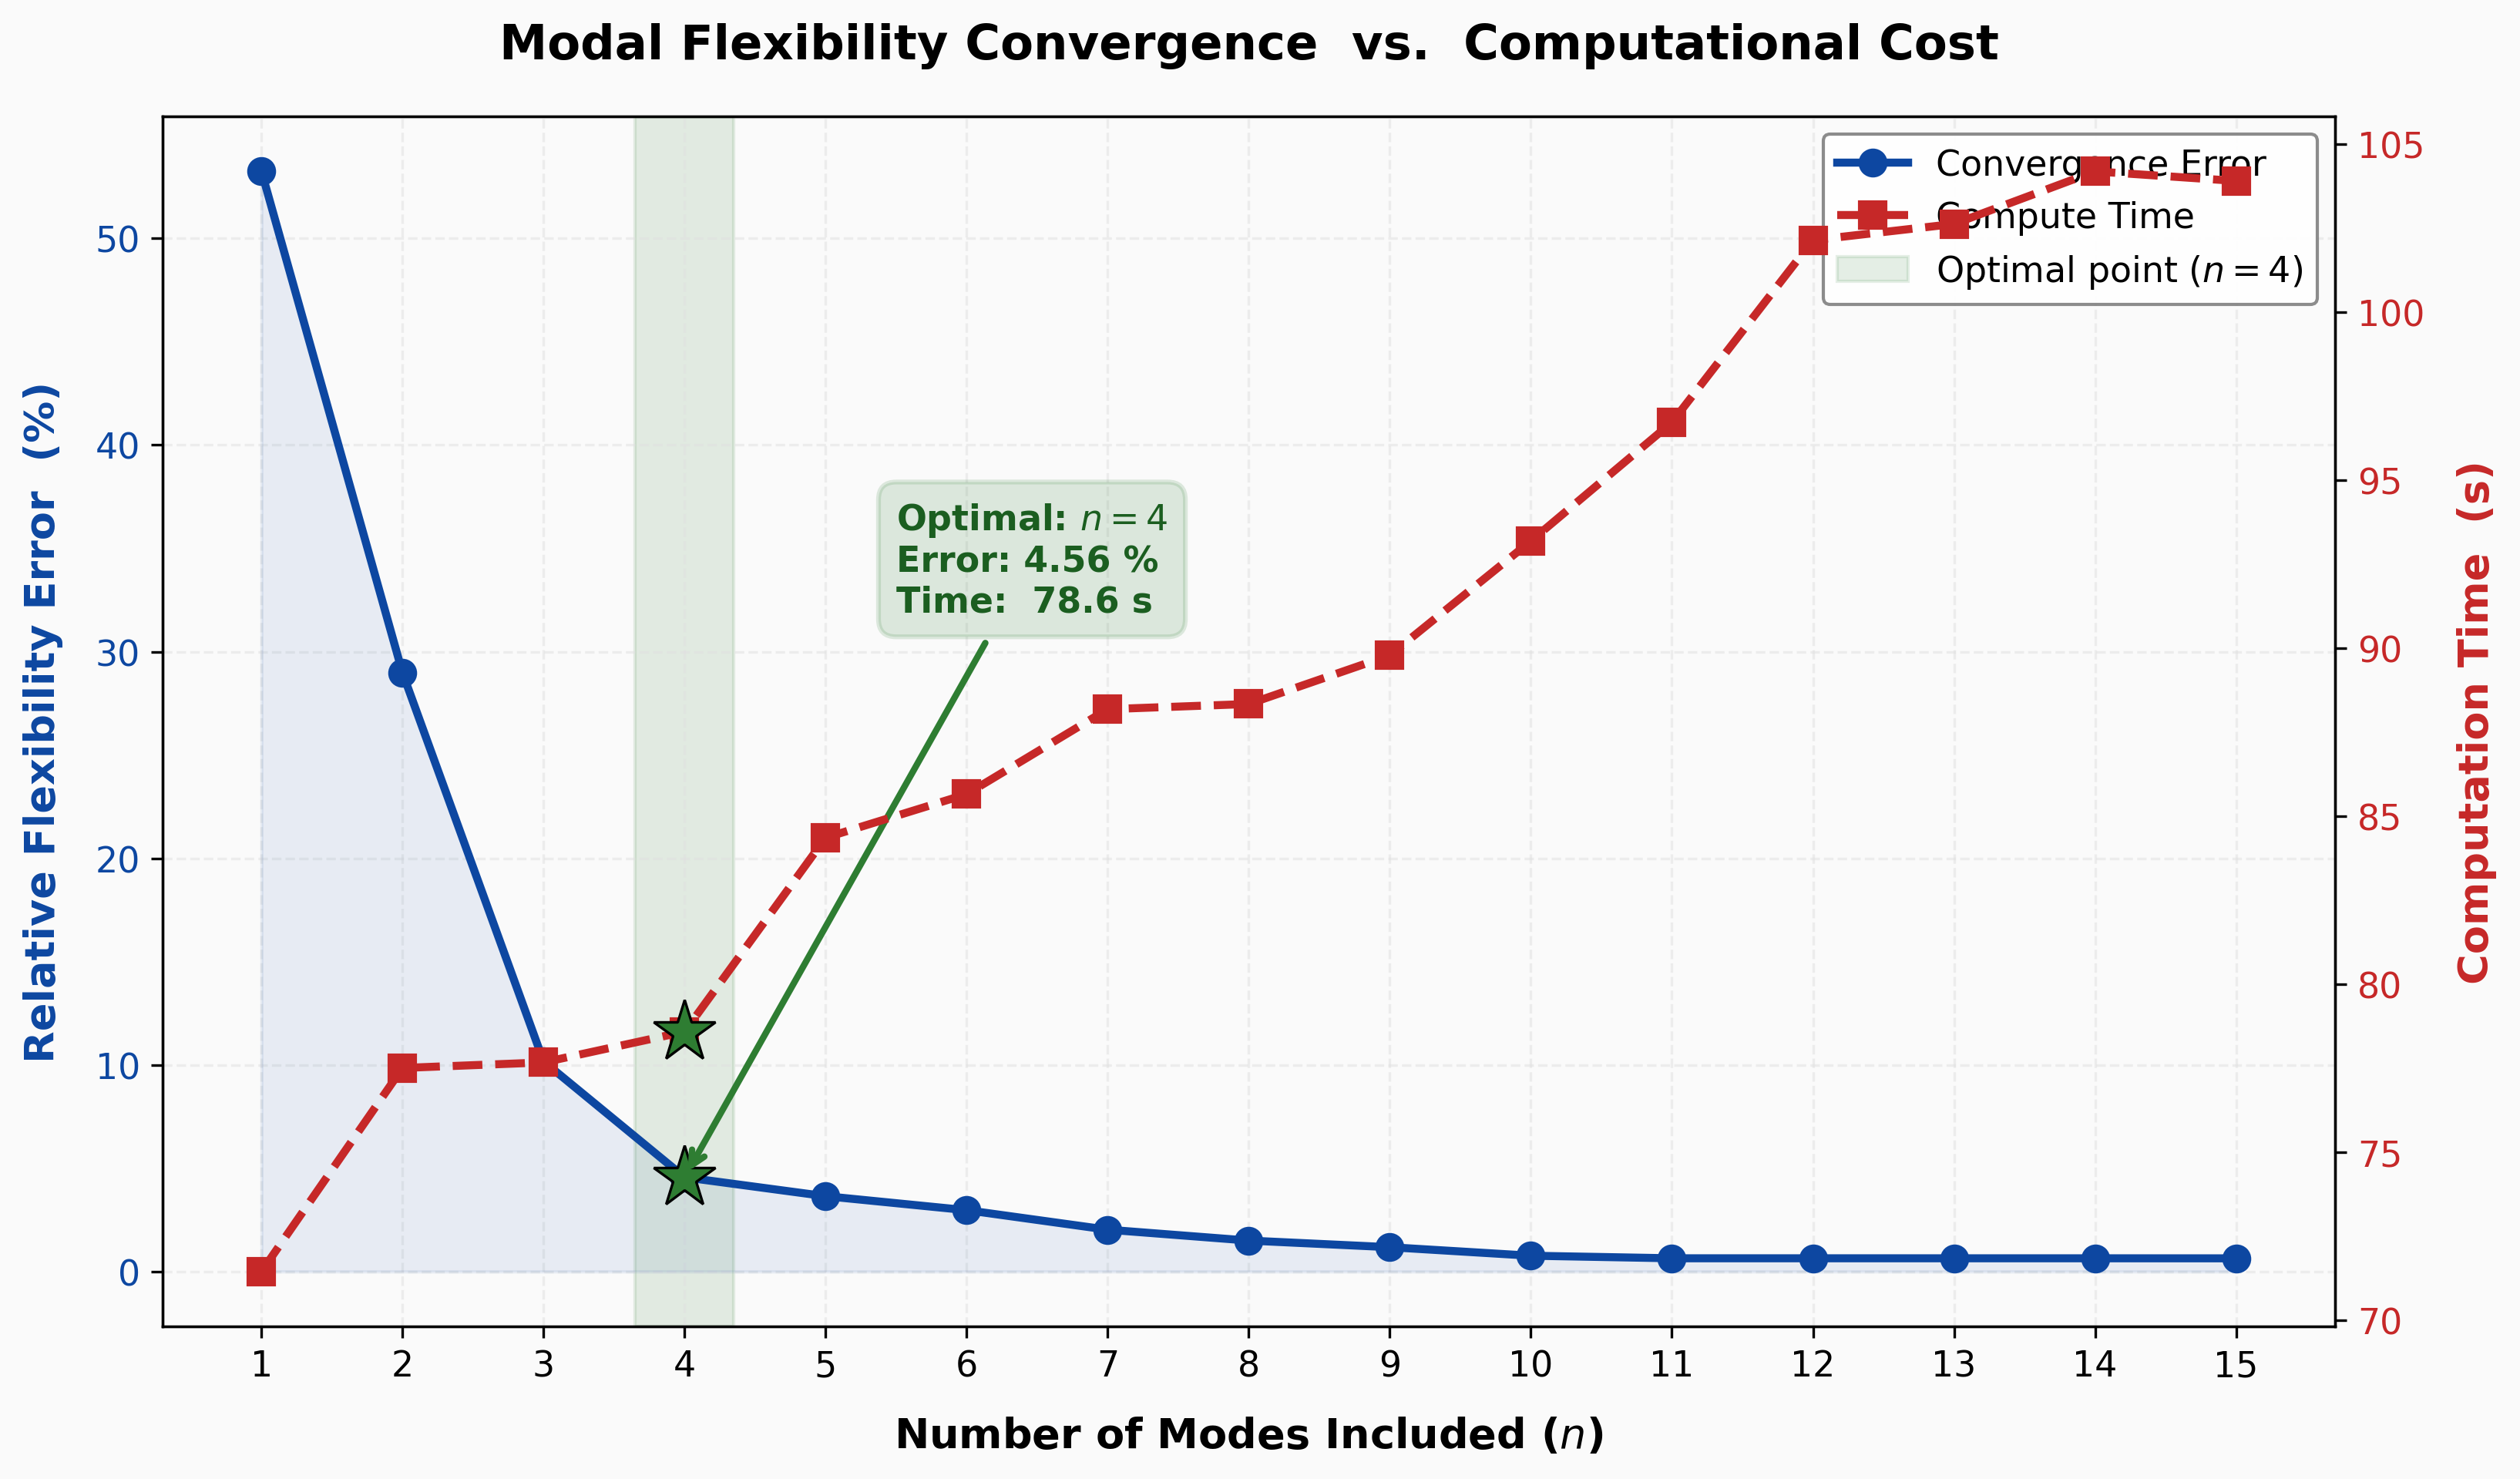

In [ ]:
from src.convergence import find_elbow, plot_convergence_vs_cost
import matplotlib.pyplot as plt

# --- Find the optimal trade-off point (Kneedle / max-distance method) ---
elbow_n, diagnostics = find_elbow(modes_range, convergence_errors, compute_times)
print(f"Optimal elbow point: n = {elbow_n} modes")
print(f"  → Error at elbow : {convergence_errors[elbow_n - 1]:.2f} %")
print(f"  → Time  at elbow : {compute_times[elbow_n - 1]:.1f} s")

# --- Generate the publication-quality Pareto trade-off figure ---
fig, (ax1, ax2) = plot_convergence_vs_cost(
    modes_range,
    convergence_errors,
    compute_times,
    elbow_n=elbow_n,
    save_path='../data/processed/convergence_vs_cost.png',
)

plt.show()